In [13]:
%matplotlib widget

In [14]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [15]:
spectra = []

for i in range(1, 21):
    df = pd.read_csv(f"Spectrum_{i}_gas_exp.csv")
    spectra.append(df)

In [16]:
def Ku03(x):
    # AGN selection based on Kauffman et al. 2003
    # log OIII/Hb > 0.61/(log NII/Ha - 0.05) + 1.3
    return 0.61/(x - 0.05) + 1.3

def Ke01(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.61/(log NII/Ha - 0.47) + 1.19
     return 0.61/(x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
     # log OIII/Hb > 0.29/(log NII/Ha +0.20) + 0.96
    return 0.29/(x + 0.20) + 0.96

def C10(x):
 # Seyfert–LINER line based on Cid Fernandes et al 2010
    return 1.01*x + 0.48

def Ke01_SII(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.72/(log SII/Ha - 0.32) + 1.3
     return 0.72/(x - 0.32) + 1.3

def Ke06(x):
    #Seyfert–LINER line
    return 1.89* x + 0.76

def error_ratio(err_1, err_2, flux_1, flux_2):
    try:
        e_1 = err_1 / (flux_1 * np.log(10)) if flux_1 != 0 else np.nan
        e_2 = err_2 / (flux_2 * np.log(10)) if flux_2 != 0 else np.nan
        return np.sqrt(e_1**2 + e_2**2)
    except:
        return np.nan

def ratio(spectrum_1):
    flux = spectrum_1['Flux']
    err_flux = spectrum_1['Error_flux']

    OIII = flux[8]
    HB   = flux[1]
    NII  = flux[12]
    HA   = flux[2]
    SII  = flux[3]

    OIII_HB = np.log10(OIII / HB) if OIII > 0 and HB > 0 else np.nan
    NII_HA  = np.log10(NII / HA)  if NII > 0 and HA > 0 else np.nan
    SII_HA  = np.log10(SII / HA)  if SII > 0 and HA > 0 else np.nan

    err_OIII_HB = error_ratio(err_flux[8], err_flux[1], OIII, HB)
    err_NII_HA  = error_ratio(err_flux[12], err_flux[2], NII, HA)
    err_SII_HA  = error_ratio(err_flux[3], err_flux[2], SII, HA)

    return OIII_HB, NII_HA, SII_HA, err_OIII_HB, err_NII_HA, err_SII_HA

0.7279475563440118 -1.185746394051241 -0.12770739101778858
0.19754474461250848 -0.6996501443528238 nan
0.10758694190996335 -0.5223648635118056 -0.9048076321637661
0.07824527817335317 -0.5851068620016265 -1.5437736458073041
0.10275711883974856 -0.6515552570408356 -1.4500725688922513
0.10926263075272996 -0.6675519293943556 -1.4415517664386663
-0.10523191133645722 -0.5448900877937115 -1.357455623426003
-0.17850917271896322 -0.479678630695532 -1.5729410640742252
-0.18916259337763874 -0.38567886868597445 -1.1240902329043188
-0.16019798751378153 -0.38501647735475664 -1.1366409916633855
-0.18520873928211412 -0.3564423626928925 -0.9516019247725319
-0.2558266172226302 -0.3391460508263556 -1.1248311433689455
-0.19586799773667637 -0.4154532285338855 -1.055347749352936
-0.10799909799612063 -0.2865016456176331 -0.7019842421362663
-0.2436544485217641 -0.3347453256941779 -0.903673896840798
0.27495806579605536 -0.1621690220020986 nan


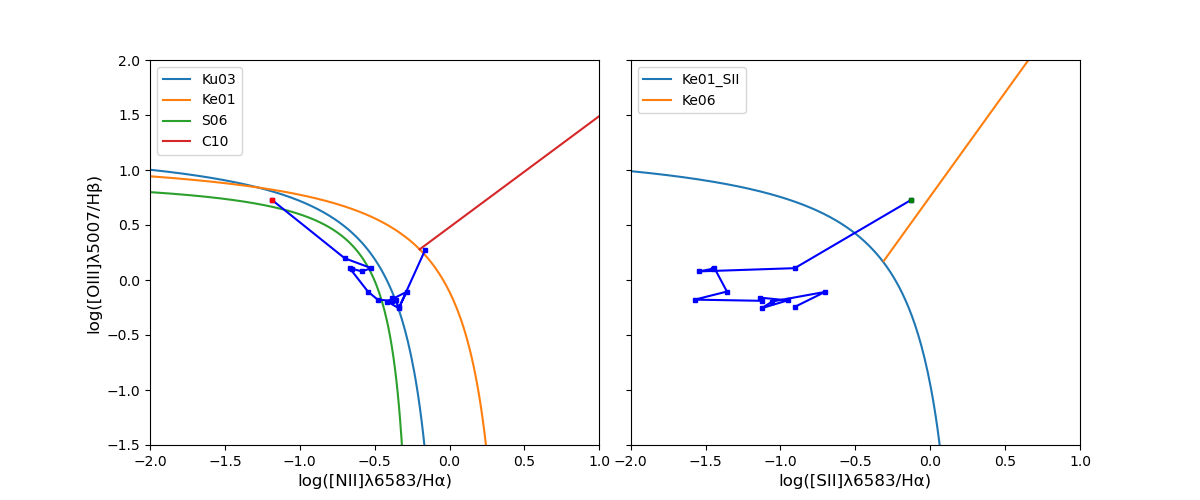

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.2, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03')
ax[0].plot(x1, Ke01(x1), label = 'Ke01')
ax[0].plot(x2, S06(x2), label = 'S06')
ax[0].plot(x3, C10(x3), label = 'C10')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01_SII')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')

NII_HA =[]
OIII_HB =[]
SII_HA =[]
OIII_HB_ok2 =[]
for i in range(2, 18):
    spectrum = spectra[i]
    oiii_hb, nii_ha, sii_ha, err_oiii_hb, err_nii_ha, err_sii_ha = ratio(spectrum)
    print(oiii_hb, nii_ha, sii_ha)
    NII_HA.append(nii_ha)
    OIII_HB.append(oiii_hb)
    if np.isnan(oiii_hb) == False and np.isnan(sii_ha) == False:
        SII_HA.append(sii_ha)
        OIII_HB_ok2.append(oiii_hb)
    
ax[0].plot(NII_HA, OIII_HB, color='blue', marker= 's', linestyle='-', markersize = 3)   
ax[0].plot(NII_HA[0], OIII_HB[0], color='red', marker= 's', linestyle='-', markersize = 3)               
ax[1].plot(SII_HA, OIII_HB_ok2, color='blue', marker= 's', linestyle='-', markersize = 3)
ax[1].plot(SII_HA[0], OIII_HB_ok2[0], color='green', marker= 's', linestyle='-', markersize = 3)

ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6583/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.07)
plt.savefig('BPT_grad.png', bbox_inches='tight')

In [18]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
image = hdul[0].data
image_error = hdul[1].data

image_cut = image[55:155, 0:1800]
image_error_cut = image_error[55:155, 0:1800]
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

Text(0.5, 1.0, 'H$\\alpha$')

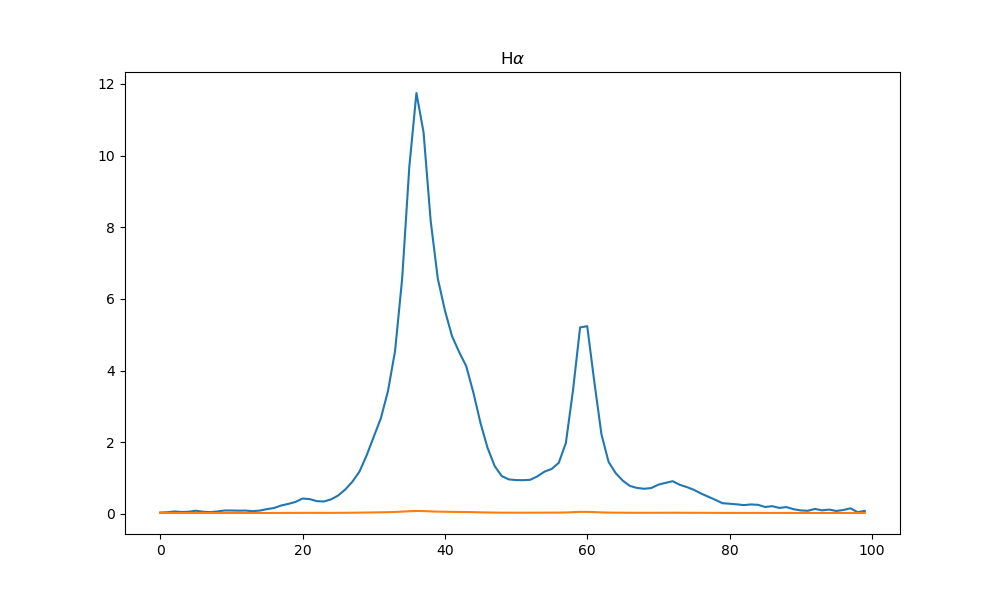

In [19]:
mask_HA = (wavelenghts > l_HA-8)*(wavelenghts < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [20]:
def agn_score(OIII_HB, NII_HA): #Rispetto a Ke01
    y = np.array(OIII_HB)
    x = np.array(NII_HA)

    if y < Ke01(x):
        return -1* np.abs(Ke01(x) - y)   
    if y == Ke01(x):
        return 0
    else:
        return 1*np.abs(Ke01(x) - y)

In [21]:
from matplotlib.collections import LineCollection


def colored_line(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified along the line by a third value.

    It does this by creating a collection of line segments. Each line segment is
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should be the same size as x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Default the capstyle to butt so that the line segments smoothly line up
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # Compute the midpoints of the line segments. Include the first and last points
    # twice so we don't need any special syntax later to handle them.
    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    # Determine the start, middle, and end coordinate pair of each line segment.
    # Use the reshape to add an extra dimension so each pair of points is in its
    # own list. Then concatenate them to create:
    # [
    #   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
    #   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
    #   ...
    # ]
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    lc = LineCollection(segments, **default_kwargs)
    lc.set_array(c)  # set the colors of each segment

    return ax.add_collection(lc)

In [22]:
score = []
for i in range(20):
    score.append(agn_score(OIII_HB[i], NII_HA[i]))

fig, ax = plt.subplots()

colored_line(x_axes, radial_profile_HA, c=score, ax=ax, cmap='rainbow')



IndexError: list index out of range

In [ ]:
for i in range(20):
    xmin = i * 5
    xmax = x_min + 5
    for j in range(100): 
        if xmin <= x_axes[j] <= xmax:
            colored_line(x_axes[j], radial_profile_HA[j], c=score, ax=ax, cmap='rainbow')
